<a href="https://colab.research.google.com/github/harishmuh/Deep-Learning-with-Pytorch-tutorials/blob/main/PyTorch_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **PyTorch Fundamentals & Tensors**

---



## Learning Objectives
By the end of this chapter, you will be able to:
- Understand PyTorch tensors and their operations
- Perform tensor manipulations for computer vision tasks
- Implement automatic differentiation with Autograd
- Build simple neural networks using PyTorch modules
- Utilize GPU acceleration for deep learning





## 1 Introduction to PyTorch

PyTorch is an open-source deep learning framework developed by Facebook's AI Research lab. It provides:
- **Dynamic Computation Graphs**: Flexible model building
- **GPU Acceleration**: CUDA support for fast training
- **Pythonic Interface**: Intuitive and easy to learn
- **Rich Ecosystem**: torchvision, torchaudio, torchtext

### Why PyTorch for Computer Vision?
- Native support for image tensors (B, C, H, W format)
- Powerful data loading with `torchvision.datasets`
- Pre-trained models for transfer learning
- Efficient GPU utilization for batch processing

In [1]:
# check installation

import torch
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: Tesla T4


---

## 2 Understanding Tensors

Tensors are the fundamental data structure in PyTorch. They are multi-dimensional arrays similar to NumPy arrays but with additional capabilities:
- **GPU acceleration**
- **Automatic differentiation**
- **Distributed computing support**

### Tensor Dimensions in Computer Vision:
| Dimension | Meaning | Example |
|-----------|---------|---------|
| 0D (scalar) | Single value | Pixel intensity = 255 |
| 1D (vector) | List of values | Class probabilities [0.1, 0.7, 0.2] |
| 2D (matrix) | Grayscale image | 224 × 224 pixel values |
| 3D (tensor) | Color image | 3 × 224 × 224 (RGB) |
| 4D (batch) | Batch of images | 32 × 3 × 224 × 224 |
| 5D (video) | Video frames | 8 × 3 × 16 × 224 × 224 |

In [2]:
# Creating Tensors

# From lists
scalar = torch.tensor(5)
vector = torch.tensor([1, 2, 3, 4, 5])
matrix = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

print(f"Scalar: {scalar}, Shape: {scalar.shape}, Dimensions: {scalar.ndim}")
print(f"Vector: {vector}, Shape: {vector.shape}, Dimensions: {vector.ndim}")
print(f"Matrix:\n{matrix}, Shape: {matrix.shape}, Dimensions: {matrix.ndim}")

# Special tensor creation methods
zeros = torch.zeros(3, 4)  # 3x4 matrix of zeros
ones = torch.ones(2, 3, 4)  # 2x3x4 tensor of ones
random = torch.rand(3, 3)   # Uniform random [0, 1)
normal = torch.randn(3, 3)  # Normal distribution N(0,1)

print(f"\nZeros tensor shape: {zeros.shape}")
print(f"Ones tensor shape: {ones.shape}")
print(f"Random tensor:\n{random}")

Scalar: 5, Shape: torch.Size([]), Dimensions: 0
Vector: tensor([1, 2, 3, 4, 5]), Shape: torch.Size([5]), Dimensions: 1
Matrix:
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]), Shape: torch.Size([3, 3]), Dimensions: 2

Zeros tensor shape: torch.Size([3, 4])
Ones tensor shape: torch.Size([2, 3, 4])
Random tensor:
tensor([[0.3418, 0.7439, 0.6439],
        [0.5686, 0.6799, 0.7653],
        [0.1436, 0.4271, 0.8039]])


In [3]:
# Creating image-like tensors (common in CV)

# Single grayscale image: 1 channel, 28x28 pixels
grayscale_image = torch.randn(1, 28, 28)
print(f"Grayscale image shape: {grayscale_image.shape}")  # (C, H, W)

# Single color image: 3 channels (RGB), 224x224 pixels
color_image = torch.randn(3, 224, 224)
print(f"Color image shape: {color_image.shape}")  # (C, H, W)

# Batch of 32 color images
batch_images = torch.randn(32, 3, 224, 224)
print(f"Batch of images shape: {batch_images.shape}")  # (B, C, H, W)

# Video batch: 8 videos, 16 frames each, 3 channels, 224x224
video_batch = torch.randn(8, 16, 3, 224, 224)
print(f"Video batch shape: {video_batch.shape}")  # (B, T, C, H, W)

Grayscale image shape: torch.Size([1, 28, 28])
Color image shape: torch.Size([3, 224, 224])
Batch of images shape: torch.Size([32, 3, 224, 224])
Video batch shape: torch.Size([8, 16, 3, 224, 224])


---

## 3 Tensor Operations

Understanding tensor operations is crucial for manipulating image data and building neural networks.

In [4]:
# Basic Arithmetic Operations

a = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
b = torch.tensor([[5, 6], [7, 8]], dtype=torch.float32)

print("Tensor A:")
print(a)
print("\nTensor B:")
print(b)

# Element-wise operations
print("\nElement-wise Addition (a + b):")
print(a + b)

print("\nElement-wise Multiplication (a * b):")
print(a * b)

print("\nMatrix Multiplication (a @ b):")
print(a @ b)

# Broadcasting
c = torch.tensor([10, 20])
print(f"\nBroadcasting: a + c = \n{a + c}")

Tensor A:
tensor([[1., 2.],
        [3., 4.]])

Tensor B:
tensor([[5., 6.],
        [7., 8.]])

Element-wise Addition (a + b):
tensor([[ 6.,  8.],
        [10., 12.]])

Element-wise Multiplication (a * b):
tensor([[ 5., 12.],
        [21., 32.]])

Matrix Multiplication (a @ b):
tensor([[19., 22.],
        [43., 50.]])

Broadcasting: a + c = 
tensor([[11., 22.],
        [13., 24.]])


In [5]:
# Tensor Reshaping - Critical for CV

# Create a batch of 4 grayscale images (28x28)
images = torch.randn(4, 1, 28, 28)
print(f"Original shape: {images.shape}")

# Flatten each image for fully connected layers
flattened = images.view(4, -1)  # -1 infers the size
print(f"Flattened shape: {flattened.shape}")  # (4, 784)

# Reshape to different dimensions
reshaped = images.view(4, 1, 14, 56)
print(f"Reshaped: {reshaped.shape}")

# Permute dimensions (change from NCHW to NHWC format)
nhwc = images.permute(0, 2, 3, 1)
print(f"NHWC format: {nhwc.shape}")

# Squeeze and Unsqueeze
squeezed = images.squeeze(1)  # Remove dimension 1
print(f"Squeezed: {squeezed.shape}")

unsqueezed = squeezed.unsqueeze(1)  # Add dimension at position 1
print(f"Unsqueezed: {unsqueezed.shape}")

Original shape: torch.Size([4, 1, 28, 28])
Flattened shape: torch.Size([4, 784])
Reshaped: torch.Size([4, 1, 14, 56])
NHWC format: torch.Size([4, 28, 28, 1])
Squeezed: torch.Size([4, 28, 28])
Unsqueezed: torch.Size([4, 1, 28, 28])


In [6]:
# Indexing and Slicing - Working with Image Regions

# Create a sample image
image = torch.randn(3, 224, 224)

# Extract the red channel
red_channel = image[0]
print(f"Red channel shape: {red_channel.shape}")

# Crop the center 112x112 region
center_crop = image[:, 56:168, 56:168]
print(f"Center crop shape: {center_crop.shape}")

# Extract top-left quadrant
top_left = image[:, :112, :112]
print(f"Top-left quadrant shape: {top_left.shape}")

# Advanced indexing
batch = torch.randn(8, 3, 32, 32)
selected = batch[[0, 2, 4, 6]]  # Select specific batch items
print(f"Selected batch shape: {selected.shape}")

Red channel shape: torch.Size([224, 224])
Center crop shape: torch.Size([3, 112, 112])
Top-left quadrant shape: torch.Size([3, 112, 112])
Selected batch shape: torch.Size([4, 3, 32, 32])


---

## 4 Tensor Data Types and Device Management

Proper data type management is essential for memory efficiency and numerical stability.

In [7]:
# Data Types in PyTorch

# Common data types for CV
float32_tensor = torch.randn(3, 224, 224, dtype=torch.float32)
float16_tensor = torch.randn(3, 224, 224, dtype=torch.float16)
uint8_tensor = torch.randint(0, 256, (3, 224, 224), dtype=torch.uint8)
int64_tensor = torch.randint(0, 1000, (10,), dtype=torch.int64)

print(f"Float32: {float32_tensor.dtype}, Memory: {float32_tensor.element_size() * float32_tensor.nelement() / 1024:.2f} KB")
print(f"Float16: {float16_tensor.dtype}, Memory: {float16_tensor.element_size() * float16_tensor.nelement() / 1024:.2f} KB")
print(f"UInt8: {uint8_tensor.dtype}, Memory: {uint8_tensor.element_size() * uint8_tensor.nelement() / 1024:.2f} KB")

# Type conversion
normalized = uint8_tensor.float() / 255.0  # Convert to [0, 1] range
print(f"\nNormalized range: [{normalized.min():.3f}, {normalized.max():.3f}]")

Float32: torch.float32, Memory: 588.00 KB
Float16: torch.float16, Memory: 294.00 KB
UInt8: torch.uint8, Memory: 147.00 KB

Normalized range: [0.000, 1.000]


In [8]:
# Device Management - CPU vs GPU

# Check available devices
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create tensor on specific device
cpu_tensor = torch.randn(1000, 1000, device='cpu')
print(f"CPU tensor device: {cpu_tensor.device}")

if torch.cuda.is_available():
    gpu_tensor = torch.randn(1000, 1000, device='cuda')
    print(f"GPU tensor device: {gpu_tensor.device}")

    # Move tensor between devices
    cpu_to_gpu = cpu_tensor.to('cuda')
    gpu_to_cpu = gpu_tensor.to('cpu')

    # Using the device variable
    flexible_tensor = torch.randn(1000, 1000, device=device)
    print(f"Flexible tensor device: {flexible_tensor.device}")

# Best practice: Use .to(device) for model and data transfer to device
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

Using device: cuda
CPU tensor device: cpu
GPU tensor device: cuda:0
Flexible tensor device: cuda:0


---

## 5 Automatic Differentiation with Autograd

Autograd is PyTorch's automatic differentiation engine. It automatically computes gradients for tensor operations, which is essential for training neural networks.

### Key Concepts:
- **Computational Graph**: Dynamic graph created during forward pass
- **Gradient Accumulation**: Gradients are accumulated by default
- `.backward()`: Computes gradients
- `.grad`: Accesses computed gradients
- `requires_grad`: Flag to track operations

In [9]:
# Understanding Autograd

# Create tensors with gradient tracking
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Define computation
z = x**2 + y**3

print(f"z = x² + y³ = {z.item()}")

# Compute gradients
z.backward()

# dz/dx = 2x = 4
# dz/dy = 3y² = 27
print(f"dz/dx = {x.grad.item()} (expected: 4)")
print(f"dz/dy = {y.grad.item()} (expected: 27)")

z = x² + y³ = 31.0
dz/dx = 4.0 (expected: 4)
dz/dy = 27.0 (expected: 27)


In [10]:
# Autograd with Tensors (Neural Network Training Context)

# Simulate a simple forward pass
torch.manual_seed(42)

# Input: batch of 4 images, each 3x32x32
input_tensor = torch.randn(4, 3, 32, 32, requires_grad=True)

# Simulate convolution operation
weights = torch.randn(16, 3, 3, 3, requires_grad=True)
bias = torch.randn(16, requires_grad=True)

# Forward pass (simplified convolution)
output = torch.nn.functional.conv2d(input_tensor, weights, bias, padding=1)
output = torch.relu(output)
output = output.mean()  # Loss computation

print(f"Output (loss): {output.item():.4f}")

# Backward pass
output.backward()

print(f"\nGradients computed:")
print(f"Input gradient shape: {input_tensor.grad.shape}")
print(f"Weights gradient shape: {weights.grad.shape}")
print(f"Bias gradient shape: {bias.grad.shape}")

# Check if gradients are non-zero
print(f"\nGradient statistics:")
print(f"Weights grad mean: {weights.grad.mean().item():.6f}")
print(f"Weights grad std: {weights.grad.std().item():.6f}")

Output (loss): 2.0257

Gradients computed:
Input gradient shape: torch.Size([4, 3, 32, 32])
Weights gradient shape: torch.Size([16, 3, 3, 3])
Bias gradient shape: torch.Size([16])

Gradient statistics:
Weights grad mean: 0.000115
Weights grad std: 0.004651


In [11]:
# Gradient Accumulation and Zeroing

# Create a simple model
x = torch.ones(3, requires_grad=True)

for epoch in range(3):
    # Forward pass
    y = (x * 2).sum()

    # Backward pass
    y.backward()

    print(f"Epoch {epoch+1}: x.grad = {x.grad}")

    # CRITICAL: Zero gradients before next iteration
    # x.grad.zero_()  # Uncomment to see the difference

print("\nNotice how gradients accumulate!")
print("In training loops, always call optimizer.zero_grad()")

Epoch 1: x.grad = tensor([2., 2., 2.])
Epoch 2: x.grad = tensor([4., 4., 4.])
Epoch 3: x.grad = tensor([6., 6., 6.])

Notice how gradients accumulate!
In training loops, always call optimizer.zero_grad()


In [12]:
# Detaching Tensors and No-Gradient Context

# Scenario: Using model output for metrics without tracking gradients

x = torch.randn(10, requires_grad=True)
y = x * 2

# Method 1: detach() - creates a new tensor without grad history
detached = y.detach()
print(f"Detached requires_grad: {detached.requires_grad}")

# Method 2: torch.no_grad() - context manager for inference
with torch.no_grad():
    z = x * 3
    print(f"No-grad context requires_grad: {z.requires_grad}")

# Method 3: @torch.no_grad() decorator for functions
@torch.no_grad()
def evaluate_model(x):
    return x * 2

result = evaluate_model(x)
print(f"Decorated function requires_grad: {result.requires_grad}")

# When to use:
# - detach(): When you need tensor values for logging/metrics
# - no_grad(): During inference/evaluation to save memory

Detached requires_grad: False
No-grad context requires_grad: False
Decorated function requires_grad: False


---

## 6 Building Neural Networks with `nn.Module`

PyTorch provides the `torch.nn` module with pre-built layers and utilities for constructing neural networks.

In [13]:
import torch.nn as nn
import torch.nn.functional as F

# Define a simple neural network for image classification
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Batch normalization
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout for regularization
        self.dropout = nn.Dropout(0.5)

        # Fully connected layers
        # After 3 poolings: 32 -> 16 -> 8 -> 4
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Conv block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 32x32 -> 16x16

        # Conv block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 16x16 -> 8x8

        # Conv block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 8x8 -> 4x4

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# Create model instance
model = SimpleCNN(num_classes=10)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


In [14]:
import torch
import torch.nn as nn

def count_parameters(model):
    """Count trainable parameters"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_summary(model, input_size=(3, 32, 32)):
    """
    Detailed model summary with:
    - Layer names
    - Output shapes
    - Parameter counts
    """

    summary = []
    hooks = []

    def register_hook(module_name):

        def hook(module, input, output):

            # Skip container modules
            if isinstance(module, (nn.Sequential, nn.ModuleList, nn.ModuleDict)):
                return

            # Get output shape
            if isinstance(output, (list, tuple)):
                output_shape = [tuple(o.shape) for o in output]
            else:
                output_shape = tuple(output.shape)

            # Count params
            params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            summary.append({
                "name": module_name,
                "type": module.__class__.__name__,
                "output_shape": output_shape,
                "params": params
            })

        return hook

    # Register hooks
    for name, module in model.named_modules():

        # Skip the whole model itself
        if name == "":
            continue

        hooks.append(
            module.register_forward_hook(register_hook(name))
        )

    # Dummy input
    device = next(model.parameters()).device
    x = torch.randn(1, *input_size).to(device)

    # Forward pass
    model.eval()
    with torch.no_grad():
        model(x)

    # Remove hooks
    for hook in hooks:
        hook.remove()

    # Print summary
    print("=" * 100)
    print(f"{'Layer':<25} {'Type':<20} {'Output Shape':<30} {'Params':<15}")
    print("=" * 100)

    total_params = 0

    for layer in summary:

        total_params += layer["params"]

        print(
            f"{layer['name']:<25} "
            f"{layer['type']:<20} "
            f"{str(layer['output_shape']):<30} "
            f"{layer['params']:<15,}"
        )

    print("=" * 100)
    print(f"Total Trainable Parameters: {count_parameters(model):,}")
    print("=" * 100)

model_summary(model)

Layer                     Type                 Output Shape                   Params         
conv1                     Conv2d               (1, 32, 32, 32)                896            
bn1                       BatchNorm2d          (1, 32, 32, 32)                64             
pool                      MaxPool2d            (1, 32, 16, 16)                0              
conv2                     Conv2d               (1, 64, 16, 16)                18,496         
bn2                       BatchNorm2d          (1, 64, 16, 16)                128            
pool                      MaxPool2d            (1, 64, 8, 8)                  0              
conv3                     Conv2d               (1, 128, 8, 8)                 73,856         
bn3                       BatchNorm2d          (1, 128, 8, 8)                 256            
pool                      MaxPool2d            (1, 128, 4, 4)                 0              
fc1                       Linear               (1, 512)     

In [15]:
# Training Loop Components

# Loss functions
criterion_ce = nn.CrossEntropyLoss()  # For multi-class classification
criterion_mse = nn.MSELoss()          # For regression
criterion_bce = nn.BCEWithLogitsLoss()  # For binary classification

# Optimizers
optimizer_sgd = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
optimizer_adam = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer_adamw = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Learning rate schedulers
scheduler_step = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=7, gamma=0.1)
scheduler_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, patience=3)
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_adam, T_max=10)

print("Loss functions, optimizers, and schedulers configured!")
print("\nCommon settings:")
print("- CrossEntropyLoss: Multi-class classification")
print("- Adam optimizer: lr=0.001 (good default)")
print("- SGD + momentum: lr=0.01, momentum=0.9 (often better convergence)")

Loss functions, optimizers, and schedulers configured!

Common settings:
- CrossEntropyLoss: Multi-class classification
- Adam optimizer: lr=0.001 (good default)
- SGD + momentum: lr=0.01, momentum=0.9 (often better convergence)


In [16]:
# Complete Training Loop Example

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(dataloader):
        # Move to device
        inputs, targets = inputs.to(device), targets.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    """Evaluate model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

print("Training and evaluation functions defined!")
print("\nKey points:")
print("- model.train() / model.eval() for mode switching")
print("- torch.no_grad() for evaluation")
print("- optimizer.zero_grad() before backward")
print("- optimizer.step() after backward")

Training and evaluation functions defined!

Key points:
- model.train() / model.eval() for mode switching
- torch.no_grad() for evaluation
- optimizer.zero_grad() before backward
- optimizer.step() after backward


---

## 7 Saving and Loading Models

Proper model checkpointing is essential for resuming training and deployment.

In [17]:
# Saving Models

# Method 1: Save only model weights (recommended for inference)
torch.save(model.state_dict(), 'model_weights.pth')
print("Model weights saved to 'model_weights.pth'")

# Method 2: Save entire model (including architecture)
torch.save(model, 'model_complete.pth')
print("Complete model saved to 'model_complete.pth'")

# Method 3: Save checkpoint (for resuming training)
checkpoint = {
    'epoch': 10,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer_adam.state_dict(),
    'loss': 0.234,
    'accuracy': 92.5,
    'class_names': ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
}
torch.save(checkpoint, 'checkpoint.pth')
print("Training checkpoint saved to 'checkpoint.pth'")

Model weights saved to 'model_weights.pth'
Complete model saved to 'model_complete.pth'
Training checkpoint saved to 'checkpoint.pth'


In [18]:
# Loading Models

# Method 1: Load weights into existing model
model_loaded = SimpleCNN(num_classes=10)
model_loaded.load_state_dict(torch.load('model_weights.pth'))
print("Model weights loaded successfully")

# Method 2: Load complete model
model_complete = torch.load('model_complete.pth', weights_only=False)
print("Complete model loaded")

# Method 3: Load checkpoint for resuming training
model_resume = SimpleCNN(num_classes=10)
optimizer_resume = torch.optim.Adam(model_resume.parameters(), lr=0.001)

checkpoint = torch.load('checkpoint.pth')
model_resume.load_state_dict(checkpoint['model_state_dict'])
optimizer_resume.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']

print(f"Resumed from epoch {epoch}, loss: {loss:.4f}")

# Set to evaluation mode for inference
model_loaded.eval()
print("\nModel set to evaluation mode")

Model weights loaded successfully
Complete model loaded
Resumed from epoch 10, loss: 0.2340

Model set to evaluation mode


---

## 8 Practical Exercise: Image Tensor Operations

Let's apply what we've learned with practical image tensor manipulations.

In [19]:
# Exercise: Create and manipulate image tensors

# Create a synthetic batch of images
torch.manual_seed(42)
batch_size = 4
images = torch.randn(batch_size, 3, 64, 64)

# Task 1: Normalize images to [0, 1] range
def normalize_tensor(tensor):
    """Normalize tensor to [0, 1] range"""
    min_val = tensor.min()
    max_val = tensor.max()
    return (tensor - min_val) / (max_val - min_val)

normalized = normalize_tensor(images)
print(f"Normalized range: [{normalized.min():.3f}, {normalized.max():.3f}]")

# Task 2: Extract center crop
def center_crop(tensor, crop_size):
    """Extract center crop from images"""
    _, c, h, w = tensor.shape
    start_h = (h - crop_size) // 2
    start_w = (w - crop_size) // 2
    return tensor[:, :, start_h:start_h+crop_size, start_w:start_w+crop_size]

cropped = center_crop(images, 32)
print(f"Cropped shape: {cropped.shape}")

# Task 3: Horizontal flip
flipped = torch.flip(images, dims=[3])  # Flip along width dimension
print(f"Flipped shape: {flipped.shape}")

# Task 4: Compute channel-wise statistics
mean_per_channel = images.mean(dim=[0, 2, 3])  # Average over batch, height, width
std_per_channel = images.std(dim=[0, 2, 3])
print(f"\nChannel-wise mean: {mean_per_channel}")
print(f"Channel-wise std: {std_per_channel}")

Normalized range: [0.000, 1.000]
Cropped shape: torch.Size([4, 3, 32, 32])
Flipped shape: torch.Size([4, 3, 64, 64])

Channel-wise mean: tensor([-0.0033,  0.0046,  0.0062])
Channel-wise std: tensor([1.0089, 1.0072, 1.0059])


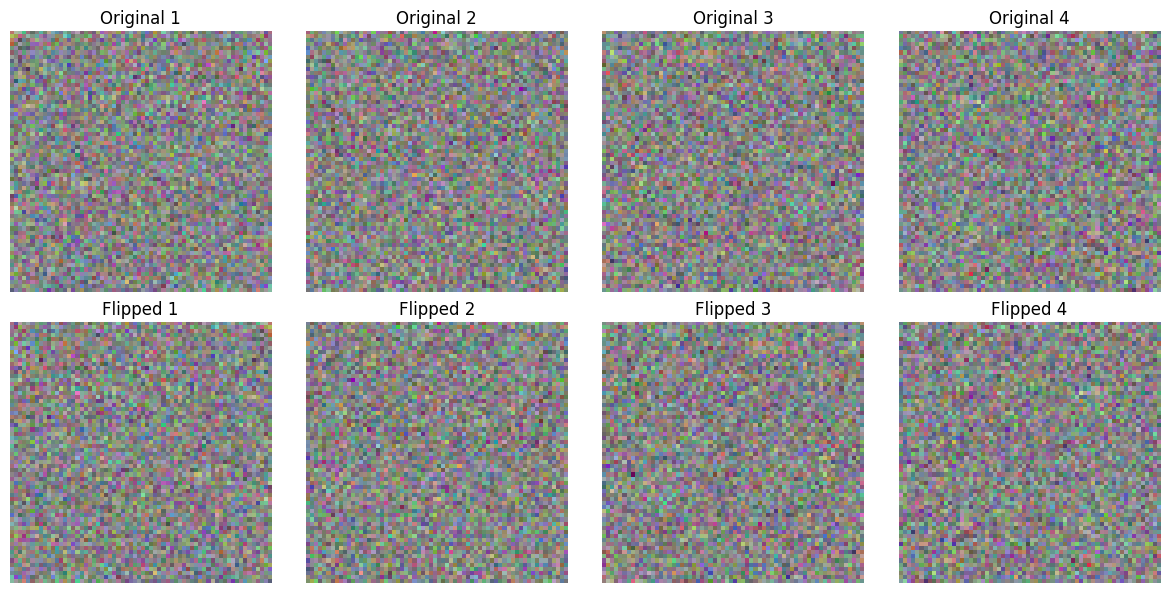


Visualization saved to 'tensor_operations.png'


In [20]:
# Visualize tensor operations
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    # Original
    img = normalized[i].permute(1, 2, 0).numpy()
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Original {i+1}')
    axes[0, i].axis('off')

    # Flipped
    img_flipped = normalize_tensor(flipped)[i].permute(1, 2, 0).numpy()
    axes[1, i].imshow(img_flipped)
    axes[1, i].set_title(f'Flipped {i+1}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('tensor_operations.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nVisualization saved to 'tensor_operations.png'")

---

## Quiz

Test your understanding of PyTorch fundamentals:

### Multiple Choice Questions

**1. What is the default memory layout for image tensors in PyTorch?**
   - a) NHWC (Batch, Height, Width, Channels)
   - b) NCHW (Batch, Channels, Height, Width) ✓
   - c) CHWN (Channels, Height, Width, Batch)
   - d) HWCN (Height, Width, Channels, Batch)

**2. What does `requires_grad=True` indicate?**
   - a) The tensor is on GPU
   - b) The tensor requires gradient computation ✓
   - c) The tensor is trainable
   - d) The tensor is a model parameter

**3. When should you use `torch.no_grad()`?**
   - a) During training
   - b) During inference/evaluation ✓
   - c) When computing gradients
   - d) When initializing weights

**4. What happens if you don't call `optimizer.zero_grad()`?**
   - a) Training fails
   - b) Gradients accumulate ✓
   - c) Model doesn't update
   - d) Nothing happens

**5. Which data type uses the least memory for storing images?**
   - a) torch.float32
   - b) torch.float16
   - c) torch.uint8 ✓
   - d) torch.int64



### Coding Exercise

**Exercise 1.1:** Create a function that:
1. Takes a batch of images (N, C, H, W)
2. Normalizes each channel using given mean and std
3. Returns the normalized batch






**Solution:**

In [21]:
def normalize_channels(images, mean, std):
    """
    Normalize images channel-wise.

    Args:
        images: Tensor of shape (N, C, H, W)
        mean: List of mean values for each channel
        std: List of std values for each channel

    Returns:
        Normalized images
    """
    mean = torch.tensor(mean).view(1, -1, 1, 1)
    std = torch.tensor(std).view(1, -1, 1, 1)

    normalized = (images - mean) / std
    return normalized

# Test
test_images = torch.randn(4, 3, 32, 32) * 50 + 100  # Random images
mean = [0.485, 0.456, 0.406]  # ImageNet means
std = [0.229, 0.224, 0.225]   # ImageNet stds

normalized = normalize_channels(test_images, mean, std)
print(f"Input mean: {test_images.mean(dim=[0,2,3])}")
print(f"Normalized mean: {normalized.mean(dim=[0,2,3])}")
print(f"Normalized std: {normalized.std(dim=[0,2,3])}")

Input mean: tensor([ 99.7869, 100.0424,  99.4121])
Normalized mean: tensor([433.6326, 444.5822, 440.0269])
Normalized std: tensor([216.7362, 223.4000, 223.1658])


**Exercise 1.2:**

Implement a simple linear regression model using PyTorch's autograd:
- Generate synthetic data: y = 2x + 1 + noise
- Initialize parameters w and b
- Train for 100 epochs using gradient descent
- Print final parameters

**Solution:**

Initial w: 0.3932, b: -0.2148
Epoch 20: Loss = 0.0085, w = 1.9830, b = 0.9950
Epoch 40: Loss = 0.0078, w = 2.0010, b = 1.0035
Epoch 60: Loss = 0.0078, w = 2.0012, b = 1.0036
Epoch 80: Loss = 0.0078, w = 2.0012, b = 1.0036
Epoch 100: Loss = 0.0078, w = 2.0012, b = 1.0036

Final parameters:
w = 2.0012 (true: 2.0)
b = 1.0036 (true: 1.0)


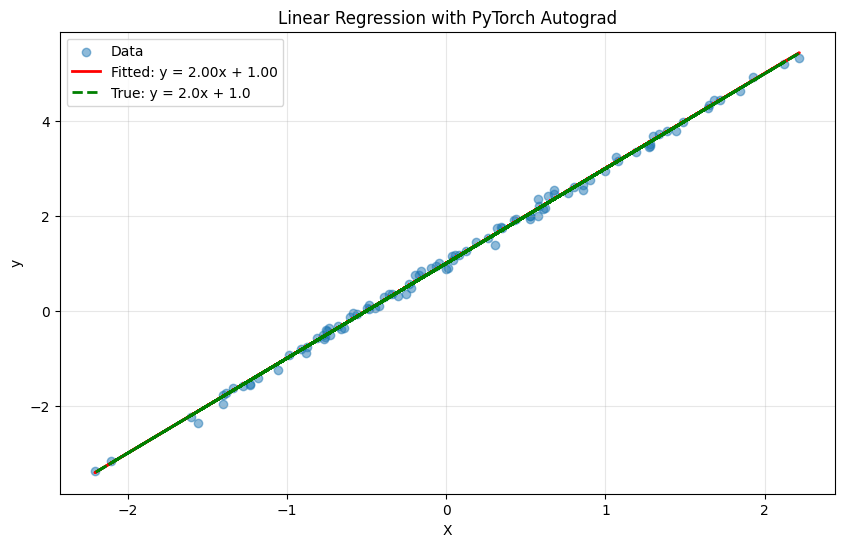

In [22]:
# Linear Regression with Autograd

# Generate synthetic data
torch.manual_seed(42)

# True parameters
true_w = 2.0
true_b = 1.0

# Generate data
n_samples = 100
X = torch.randn(n_samples, 1)
y = true_w * X + true_b + 0.1 * torch.randn(n_samples, 1)  # Add noise

# Initialize parameters
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print(f"Initial w: {w.item():.4f}, b: {b.item():.4f}")

# Training hyperparameters
learning_rate = 0.1
n_epochs = 100

# Training loop
for epoch in range(n_epochs):
    # Forward pass
    y_pred = w * X + b

    # Compute loss (MSE)
    loss = ((y_pred - y) ** 2).mean()

    # Backward pass
    loss.backward()

    # Update parameters (gradient descent)
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

        # Zero gradients
        w.grad.zero_()
        b.grad.zero_()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}, w = {w.item():.4f}, b = {b.item():.4f}")

print(f"\nFinal parameters:")
print(f"w = {w.item():.4f} (true: {true_w})")
print(f"b = {b.item():.4f} (true: {true_b})")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(X.numpy(), y.numpy(), alpha=0.5, label='Data')
plt.plot(X.numpy(), (w.item() * X + b.item()).numpy(), 'r-',
         label=f'Fitted: y = {w.item():.2f}x + {b.item():.2f}', linewidth=2)
plt.plot(X.numpy(), (true_w * X + true_b).numpy(), 'g--',
         label=f'True: y = {true_w}x + {true_b}', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Linear Regression with PyTorch Autograd')
plt.grid(True, alpha=0.3)
plt.savefig('linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Summary

In this chapter, we have learned:

### Key Concepts
1. **Tensors**: Multi-dimensional arrays with GPU support and automatic differentiation
2. **Tensor Operations**: Reshaping, indexing, broadcasting for image manipulation
3. **Autograd**: Automatic gradient computation for training neural networks
4. **nn.Module**: Building neural networks with PyTorch's modular API
5. **Training Loop**: Forward pass, loss computation, backward pass, parameter update
6. **Model Checkpointing**: Saving and loading models for deployment and resuming training

### Best Practices
- Always check tensor shapes before operations
- Use appropriate data types (float32 for training, uint8 for images)
- Move models and data to GPU when available
- Call `optimizer.zero_grad()` before `backward()`
- Use `torch.no_grad()` during inference
- Save checkpoints with optimizer state for resuming training





## Additional Resources

- [PyTorch Official Tutorials](https://pytorch.org/tutorials/)
- [PyTorch Documentation](https://pytorch.org/docs/stable/index.html)
- [Deep Learning with PyTorch Book](https://pytorch.org/deep-learning-with-pytorch-book)
- [PyTorch Forums](https://discuss.pytorch.org/)
